In [ ]:
!pip install ultralytics

from ultralytics import YOLO
import torch


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 29.7 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
!pip install opencv-python
!pip install matplotlib


In [ ]:
import os
import shutil
import random
import yaml
import cv2
import matplotlib.pyplot as plt
import pandas as pd
from ultralytics import YOLO


In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"rakshi123","key":"4a05a4fd5e7fbc6a90725f723e4644f9"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


In [ ]:
!kaggle datasets download -d icebearogo/german-traffic-sign-detection-gtsdb-dataset


Dataset URL: https://www.kaggle.com/datasets/icebearogo/german-traffic-sign-detection-gtsdb-dataset
License(s): Attribution-NonCommercial 4.0 International (CC BY-NC 4.0)
 51% 120M/234M [00:00<00:00, 1.23GB/s]
100% 234M/234M [00:00<00:00, 685MB/s] 


In [ ]:
!unzip german-traffic-sign-detection-gtsdb-dataset.zip

Archive:  german-traffic-sign-detection-gtsdb-dataset.zip
  inflating: GTSDB_Train_and_Test/ReadME__(yes actually take a look).txt  
  inflating: GTSDB_Train_and_Test/Test/images/00600.jpg  
  inflating: GTSDB_Train_and_Test/Test/images/00601.jpg  
  inflating: GTSDB_Train_and_Test/Test/images/00602.jpg  
  inflating: GTSDB_Train_and_Test/Test/images/00603.jpg  
  inflating: GTSDB_Train_and_Test/Test/images/00604.jpg  
  inflating: GTSDB_Train_and_Test/Test/images/00605.jpg  
  inflating: GTSDB_Train_and_Test/Test/images/00606.jpg  
  inflating: GTSDB_Train_and_Test/Test/images/00607.jpg  
  inflating: GTSDB_Train_and_Test/Test/images/00608.jpg  
  inflating: GTSDB_Train_and_Test/Test/images/00609.jpg  
  inflating: GTSDB_Train_and_Test/Test/images/00610.jpg  
  inflating: GTSDB_Train_and_Test/Test/images/00611.jpg  
  inflating: GTSDB_Train_and_Test/Test/images/00612.jpg  
  inflating: GTSDB_Train_and_Test/Test/images/00613.jpg  
  inflating: GTSDB_Train_and_Test/Test/images/00614.jpg

In [ ]:
!ls


german-traffic-sign-detection-gtsdb-dataset.zip  kaggle.json
GTSDB_Train_and_Test				 sample_data


In [ ]:
!ls GTSDB_Train_and_Test

'ReadME__(yes actually take a look).txt'   Test   Train


In [ ]:
!ls GTSDB_Train_and_Test/Train

images	labels


In [ ]:
print("Train images:",
      len(os.listdir("/content/GTSDB_Train_and_Test/Train")))

print("Validation images:",
      len(os.listdir("/content/GTSDB_Train_and_Test/Test")))


Train images: 2
Validation images: 2


In [ ]:
import os

os.makedirs("datasets/traffic/images/train", exist_ok=True)
os.makedirs("datasets/traffic/images/val", exist_ok=True)
os.makedirs("datasets/traffic/images/test", exist_ok=True)

os.makedirs("datasets/traffic/labels/train", exist_ok=True)
os.makedirs("datasets/traffic/labels/val", exist_ok=True)
os.makedirs("datasets/traffic/labels/test", exist_ok=True)

print("Folders created!")


Folders created!


In [ ]:
import os
import random
import shutil

source_images = "GTSDB_Train_and_Test/Train/images"
source_labels = "GTSDB_Train_and_Test/Train/labels"

all_images = os.listdir(source_images)
random.shuffle(all_images)

split_index = int(0.8 * len(all_images))

train_imgs = all_images[:split_index]
val_imgs = all_images[split_index:]

# Copy train data
for img in train_imgs:
    shutil.copy(os.path.join(source_images, img),
                "datasets/traffic/images/train/" + img)

    label = img.replace(".jpg", ".txt")
    label_path = os.path.join(source_labels, label)

    if os.path.exists(label_path):
        shutil.copy(label_path,
                    "datasets/traffic/labels/train/" + label)

# Copy validation data
for img in val_imgs:
    shutil.copy(os.path.join(source_images, img),
                "datasets/traffic/images/val/" + img)

    label = img.replace(".jpg", ".txt")
    label_path = os.path.join(source_labels, label)

    if os.path.exists(label_path):
        shutil.copy(label_path,
                    "datasets/traffic/labels/val/" + label)

print("Train/Val split done successfully!")


Train/Val split done successfully!


In [ ]:
import os
import shutil

test_images = "GTSDB_Train_and_Test/Test/images"
test_labels = "GTSDB_Train_and_Test/Test/labels"

for img in os.listdir(test_images):

    # Copy image
    shutil.copy(os.path.join(test_images, img),
                "datasets/traffic/images/test/" + img)

    # Prepare label name
    label = img.replace(".jpg", ".txt")
    label_path = os.path.join(test_labels, label)

    # Copy only if label exists
    if os.path.exists(label_path):
        shutil.copy(label_path,
                    "datasets/traffic/labels/test/" + label)

print("Test data copied successfully!")


Test data copied successfully!


In [ ]:
print("Test Images:",
      len(os.listdir("datasets/traffic/images/test")))

print("Test Labels:",
      len(os.listdir("datasets/traffic/labels/test")))


Test Images: 300
Test Labels: 235


In [ ]:
import yaml
import os

traffic_yaml = {
    'path': os.path.abspath('datasets/traffic'),
    'train': 'images/train',
    'val': 'images/val',
    'test': 'images/test',
    'nc': 5,
    'names': ['speed_limit', 'stop', 'no_entry', 'yield', 'pedestrian_crossing']
}

with open('traffic.yaml', 'w') as f:
    yaml.dump(traffic_yaml, f)

print("traffic.yaml created successfully!")


traffic.yaml created successfully!


In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

model.train(
    data="traffic.yaml",
    epochs=30,
    imgsz=640,
    batch=16,
    name="task1_traffic"
)


Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.9.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=traffic.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=task1_traffic, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective=0.0, plot

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7d3c8bf40b30>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
        

In [ ]:
model = YOLO("runs/detect/task1_traffic/weights/best.pt")

val_metrics = model.val(data="traffic.yaml")

print("Validation mAP50:", val_metrics.box.map50)


Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.9.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,623 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3259.6±1063.9 MB/s, size: 296.2 KB)
val: Scanning /content/datasets/traffic/labels/val.cache... 105 images, 15 backgrounds, 80 corrupt: 100% ━━━━━━━━━━━━ 120/120 41.9Mit/s 0.0s
val: /content/datasets/traffic/images/val/00000.jpg: ignoring corrupt image/label: Label class 11 exceeds dataset class count 5. Possible class labels are 0-4
val: /content/datasets/traffic/images/val/00022.jpg: ignoring corrupt image/label: Label class 27 exceeds dataset class count 5. Possible class labels are 0-4
val: /content/datasets/traffic/images/val/00035.jpg: ignoring corrupt image/label: Label class 13 exceeds dataset class count 5. Possible class labels are 0-4
val: /content/datasets/traffic/images/val/00037.jpg: ignoring corrupt image/label: Label class 38 exceeds dataset class count 5. Possi

In [ ]:
test_metrics = model.val(data="traffic.yaml", split="test")

print("Test mAP50:", test_metrics.box.map50)


Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.9.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2572.8±850.2 MB/s, size: 160.4 KB)
val: Scanning /content/datasets/traffic/labels/test... 235 images, 65 backgrounds, 186 corrupt: 100% ━━━━━━━━━━━━ 300/300 3.5Kit/s 0.1s
val: /content/datasets/traffic/images/test/00601.jpg: ignoring corrupt image/label: Label class 40 exceeds dataset class count 5. Possible class labels are 0-4
val: /content/datasets/traffic/images/test/00602.jpg: ignoring corrupt image/label: Label class 41 exceeds dataset class count 5. Possible class labels are 0-4
val: /content/datasets/traffic/images/test/00604.jpg: ignoring corrupt image/label: Label class 24 exceeds dataset class count 5. Possible class labels are 0-4
val: /content/datasets/traffic/images/test/00605.jpg: ignoring corrupt image/label: Label class 34 exceeds dataset class count 5. Possible class labels are 0-4
val: /content/datasets/traffic/images/test/00606.jpg: ign

In [ ]:
from ultralytics import YOLO

# Load traffic trained model
model = YOLO("runs/detect/task1_traffic/weights/best.pt")

print("Traffic model loaded successfully")


Traffic model loaded successfully


In [ ]:
!kaggle datasets download -d abdallahwagih/cars-detection

Dataset URL: https://www.kaggle.com/datasets/abdallahwagih/cars-detection
License(s): apache-2.0
  0% 0.00/38.2M [00:00<?, ?B/s]
100% 38.2M/38.2M [00:00<00:00, 1.62GB/s]


In [ ]:
!unzip cars-detection.zip

Archive:  cars-detection.zip
  inflating: Cars Detection/data.yaml  
  inflating: Cars Detection/test/images/00dea1edf14f09ab_jpg.rf.3f17c8790a68659d03b1939a59ccda80.jpg  
  inflating: Cars Detection/test/images/00dea1edf14f09ab_jpg.rf.KJ730oDTFPdXdJxvSLnX.jpg  
  inflating: Cars Detection/test/images/00e481ea1a520175_jpg.rf.6e6a8b3b45c9a11d106958f88ff714ea.jpg  
  inflating: Cars Detection/test/images/00e481ea1a520175_jpg.rf.MV6sZ8QCFwFeMYaI2tHm.jpg  
  inflating: Cars Detection/test/images/08c8b73e0c2e296e_jpg.rf.7IkYAamjZhnwsoXSrwKt.jpg  
  inflating: Cars Detection/test/images/08c8b73e0c2e296e_jpg.rf.effa65856584463c08848031cab357b9.jpg  
  inflating: Cars Detection/test/images/10c26c6598677a1f_jpg.rf.USCbBYVcUICkLhuq07Lw.jpg  
  inflating: Cars Detection/test/images/10c26c6598677a1f_jpg.rf.f72b2b91e750909f68fffeee777e9350.jpg  
  inflating: Cars Detection/test/images/1ef77c61856d3b4b_jpg.rf.HZMSiUVx3WUcMIooJMZX.jpg  
  inflating: Cars Detection/test/images/1ef77c61856d3b4b_jpg.rf.

In [ ]:
import os

print(os.listdir())
print(os.listdir("Cars Detection"))


['.config', 'No_Apply_Grayscale', 'kaggle.json', 'yolo26n.pt', 'traffic.yaml', 'SampleVideo_LowQuality.mp4', 'Apply_Grayscale', 'cars-detection.zip', 'Cars Detection', '.ipynb_checkpoints', 'german-traffic-sign-detection-gtsdb-dataset.zip', 'yolov8n.pt', 'GTSDB_Train_and_Test', 'runs', 'Sample_Video_HighQuality.mp4', 'datasets', 'sample_data']
['train', 'data.yaml', 'valid', 'test']


In [ ]:
import yaml
import os

cars_yaml = {
    'path': os.path.abspath("Cars Detection"),
    'train': 'train/images',
    'val': 'valid/images',
    'test': 'test/images',
    'nc': 5,
    'names': ['ambulance', 'bus', 'car', 'motorcycle', 'truck']
}

with open('cars.yaml', 'w') as f:
    yaml.dump(cars_yaml, f)

print("cars.yaml created successfully")


cars.yaml created successfully


In [ ]:
from ultralytics import YOLO

# Load traffic trained model
model = YOLO("runs/detect/task1_traffic/weights/best.pt")

print("Traffic model loaded for Task 2")


Traffic model loaded for Task 2


In [ ]:
model.train(
    data='cars.yaml',
    epochs=40,
    imgsz=640,
    batch=16,
    project='continual_experiment',
    name='cars_after_traffic_withoutCL',
    exist_ok=True
)


Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.9.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=cars.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=40, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=runs/detect/task1_traffic/weights/best.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=cars_after_traffic_withoutCL, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7d3c8cc73230>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
        

In [ ]:
cars_model = YOLO("runs/detect/continual_experiment/cars_after_traffic_withoutCL/weights/best.pt")

cars_metrics = cars_model.val(data='cars.yaml')

print("Cars mAP50:", cars_metrics.box.map50)


Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.9.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,623 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1073.4±411.3 MB/s, size: 31.0 KB)
val: Scanning /content/Cars Detection/valid/labels.cache... 250 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 250/250 87.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 16/16 3.3it/s 4.8s
                   all        250        454      0.666      0.613       0.63      0.468
             ambulance         50         64      0.744      0.816      0.864      0.764
                   bus         30         46       0.75      0.696      0.702      0.573
                   car         90        238      0.633      0.437      0.505      0.352
            motorcycle         42         46      0.645      0.652      0.551      0.294
                 truck         38         6

In [ ]:
traffic_metrics_after = cars_model.val(data='traffic.yaml')

print("Traffic mAP50 AFTER car training:", traffic_metrics_after.box.map50)


Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.9.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1024.2±942.0 MB/s, size: 245.1 KB)
val: Scanning /content/datasets/traffic/labels/val.cache... 105 images, 15 backgrounds, 80 corrupt: 100% ━━━━━━━━━━━━ 120/120 50.3Mit/s 0.0s
val: /content/datasets/traffic/images/val/00000.jpg: ignoring corrupt image/label: Label class 11 exceeds dataset class count 5. Possible class labels are 0-4
val: /content/datasets/traffic/images/val/00022.jpg: ignoring corrupt image/label: Label class 27 exceeds dataset class count 5. Possible class labels are 0-4
val: /content/datasets/traffic/images/val/00035.jpg: ignoring corrupt image/label: Label class 13 exceeds dataset class count 5. Possible class labels are 0-4
val: /content/datasets/traffic/images/val/00037.jpg: ignoring corrupt image/label: Label class 38 exceeds dataset class count 5. Possible class labels are 0-4
val: /content/datasets/traffic/images/val/00062.jpg: ign

In [ ]:
from ultralytics import YOLO

traffic_model = YOLO("runs/detect/task1_traffic/weights/best.pt")

traffic_metrics_before = traffic_model.val(data='traffic.yaml')

traffic_map_before = traffic_metrics_before.box.map50

print("Traffic mAP BEFORE vehicle training:", traffic_map_before)


Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.9.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,623 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1561.7±1411.9 MB/s, size: 318.2 KB)
val: Scanning /content/datasets/traffic/labels/val.cache... 105 images, 15 backgrounds, 80 corrupt: 100% ━━━━━━━━━━━━ 120/120 36.0Mit/s 0.0s
val: /content/datasets/traffic/images/val/00000.jpg: ignoring corrupt image/label: Label class 11 exceeds dataset class count 5. Possible class labels are 0-4
val: /content/datasets/traffic/images/val/00022.jpg: ignoring corrupt image/label: Label class 27 exceeds dataset class count 5. Possible class labels are 0-4
val: /content/datasets/traffic/images/val/00035.jpg: ignoring corrupt image/label: Label class 13 exceeds dataset class count 5. Possible class labels are 0-4
val: /content/datasets/traffic/images/val/00037.jpg: ignoring corrupt image/label: Label class 38 exceeds dataset class count 5. Possi

In [ ]:
cars_model = YOLO("runs/detect/continual_experiment/cars_after_traffic_withoutCL/weights/best.pt")

traffic_metrics_after = cars_model.val(data='traffic.yaml')

traffic_map_after = traffic_metrics_after.box.map50

print("Traffic mAP AFTER vehicle training:", traffic_map_after)


Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.9.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,623 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 580.7±1143.3 MB/s, size: 277.4 KB)
val: Scanning /content/datasets/traffic/labels/val.cache... 105 images, 15 backgrounds, 80 corrupt: 100% ━━━━━━━━━━━━ 120/120 25.2Mit/s 0.0s
val: /content/datasets/traffic/images/val/00000.jpg: ignoring corrupt image/label: Label class 11 exceeds dataset class count 5. Possible class labels are 0-4
val: /content/datasets/traffic/images/val/00022.jpg: ignoring corrupt image/label: Label class 27 exceeds dataset class count 5. Possible class labels are 0-4
val: /content/datasets/traffic/images/val/00035.jpg: ignoring corrupt image/label: Label class 13 exceeds dataset class count 5. Possible class labels are 0-4
val: /content/datasets/traffic/images/val/00037.jpg: ignoring corrupt image/label: Label class 38 exceeds dataset class count 5. Possib

In [ ]:
cars_metrics = cars_model.val(data='cars.yaml')

cars_map = cars_metrics.box.map50

print("Cars mAP:", cars_map)


Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.9.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 719.3±148.8 MB/s, size: 31.9 KB)
val: Scanning /content/Cars Detection/valid/labels.cache... 250 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 250/250 74.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 16/16 3.1it/s 5.1s
                   all        250        454      0.666      0.613       0.63      0.468
             ambulance         50         64      0.744      0.816      0.864      0.764
                   bus         30         46       0.75      0.696      0.702      0.573
                   car         90        238      0.633      0.437      0.505      0.352
            motorcycle         42         46      0.645      0.652      0.551      0.294
                 truck         38         60      0.558      0.467      0.527      0.356
Speed: 5.1ms preprocess, 4.4ms infe

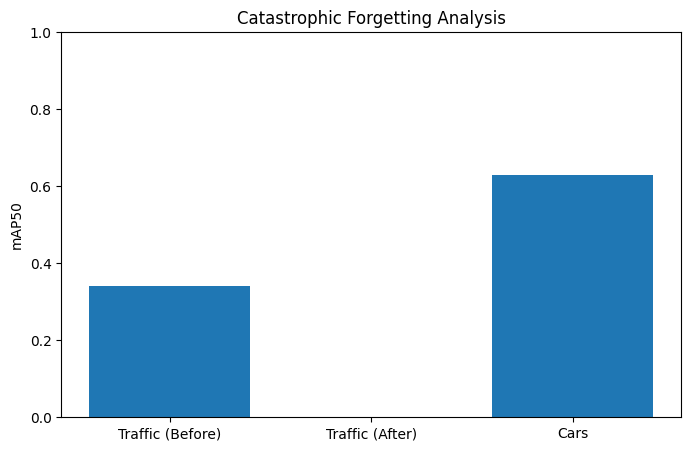

Forgetting Amount: 0.3394716796767793


In [ ]:
import matplotlib.pyplot as plt

labels = ['Traffic (Before)', 'Traffic (After)', 'Cars']
values = [traffic_map_before, traffic_map_after, cars_map]

plt.figure(figsize=(8,5))
plt.bar(labels, values)
plt.ylabel("mAP50")
plt.title("Catastrophic Forgetting Analysis")
plt.ylim(0,1)
plt.show()

print("Forgetting Amount:", traffic_map_before - traffic_map_after)
